In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Go up one level from doomsday/ to habitability/
sys.path.insert(0, str(Path.cwd().parent))
from calculator import SeaIceCalc, Habitability, SST, SRD, Tempdiff, Tempdiffall

Open the file

In [2]:
file = "../../solarflux/stability/run_0.1_5yr/output.nc"
ds = xr.open_dataset(file)
# ds_crop = ds.sel(time=slice("2002-01-01", "2002-12-31"))

Extract habitability for each month

In [3]:
results_hab = []
yearly_data = ds.groupby("time.year")

In [4]:
for year, year_ds in yearly_data:

    hab = {
        "month": None,
        "sm_tot": [],  "sm_nhem": [],  "sm_shem": [],
        "st_tot": [],  "st_nhem": [],  "st_shem": [],
        "tsurf_tot": [], "tsurf_nhem": [], "tsurf_shem": [],
    }

    monthly_data = year_ds.groupby("time.month")
    months = np.array(sorted(monthly_data.groups.keys()), dtype=int)
    hab["month"] = months

    for month, month_ds in monthly_data:

        # Whole globe
        fraction_sm = Habitability.fraction(month_ds, "sm")[0]
        fraction_st = Habitability.fraction(month_ds, "st")[0]
        fraction_tsurf = Habitability.fraction(month_ds, "tsurf")[0]

        hab["sm_tot"].append(fraction_sm)
        hab["st_tot"].append(fraction_st)
        hab["tsurf_tot"].append(fraction_tsurf)
    
        # Northern hemisphere
        sm_n = Habitability.fraction(month_ds, "sm", lat=slice(0,24))[0]
        st_n = Habitability.fraction(month_ds, "st", lat=slice(0,24))[0]
        tsurf_n = Habitability.fraction(month_ds, "tsurf", lat=slice(0,24))[0]

        hab["sm_nhem"].append(sm_n)
        hab["st_nhem"].append(st_n)
        hab["tsurf_nhem"].append(tsurf_n)

        # Southern hemisphere
        sm_s = Habitability.fraction(month_ds, "sm", lat=slice(24,48))[0]
        st_s = Habitability.fraction(month_ds, "st", lat=slice(24,48))[0]
        tsurf_s = Habitability.fraction(month_ds, "tsurf", lat=slice(24,48))[0]

        hab["sm_shem"].append(sm_s)
        hab["st_shem"].append(st_s)
        hab["tsurf_shem"].append(tsurf_s)
    
    # convert lists of scalars to numpy arrays for math/plotting later
    for k, v in list(hab.items()):
        # keep 'month' as-is (already an array)
        if k == "month":
            continue
        # convert lists to numpy arrays
        if isinstance(v, list):
            hab[k] = np.array(v) 
    
    # Store results
    results_hab.append({"year": year, "data": hab})

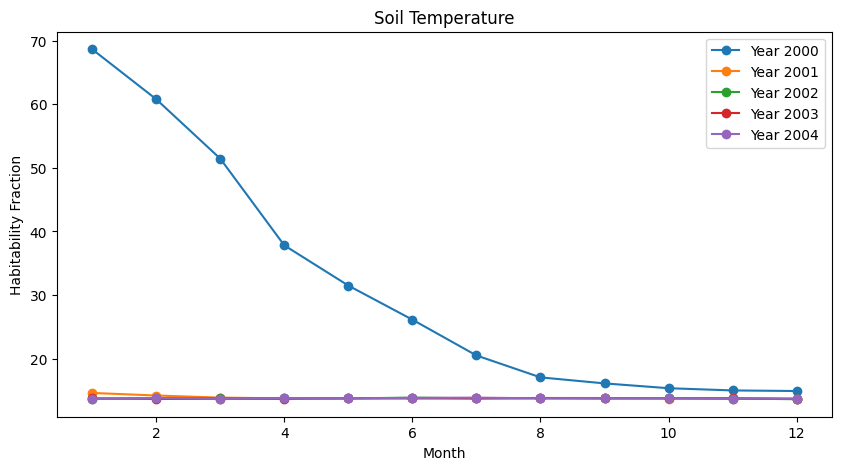

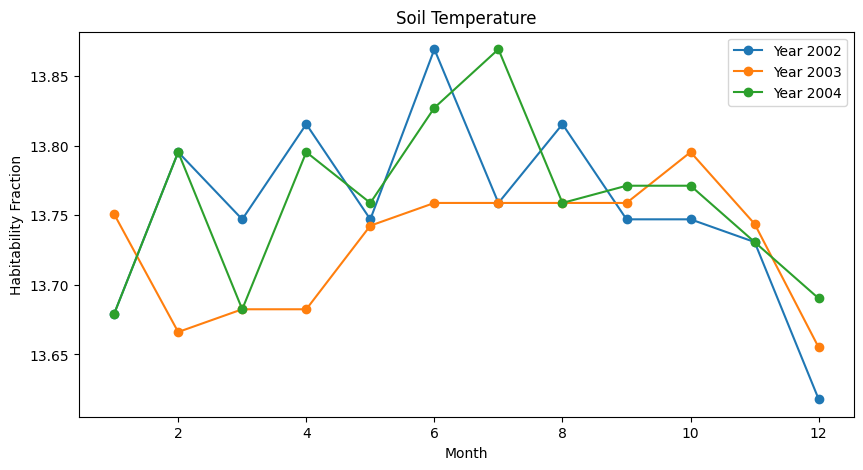

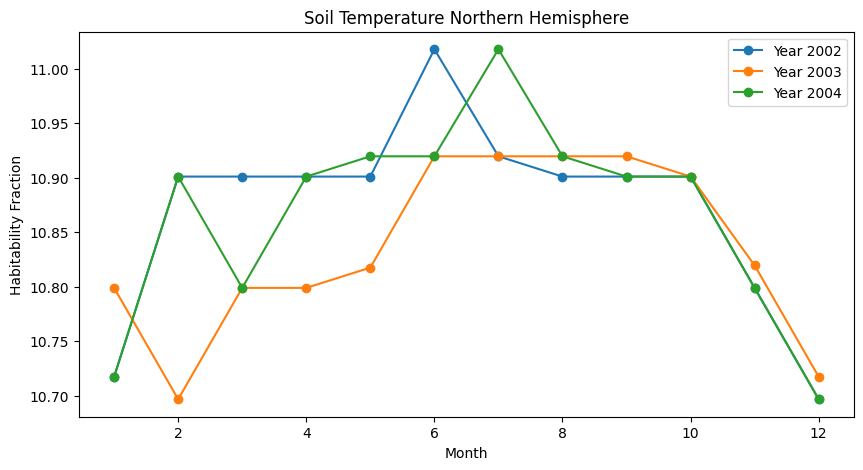

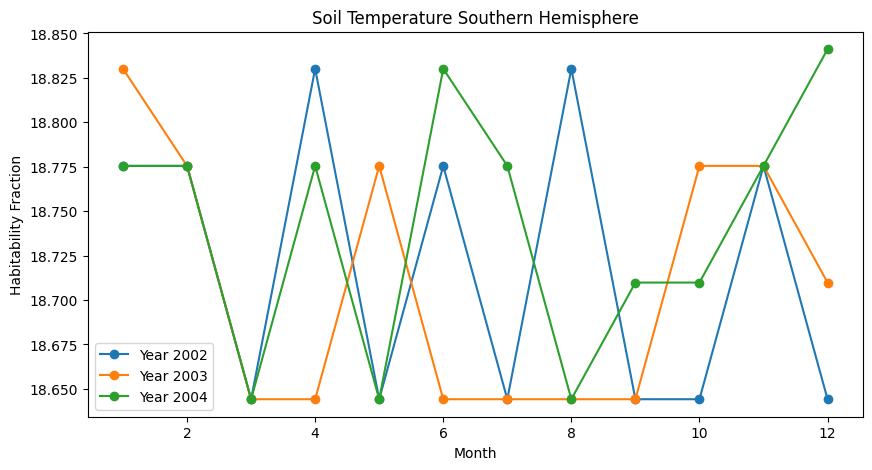

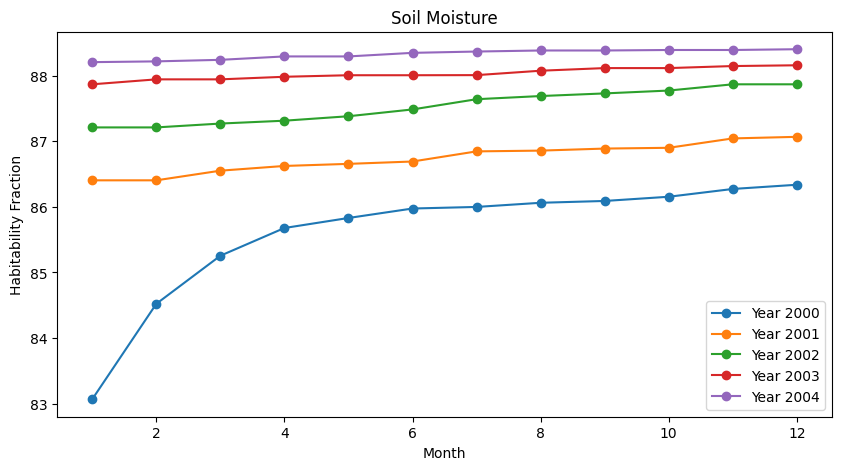

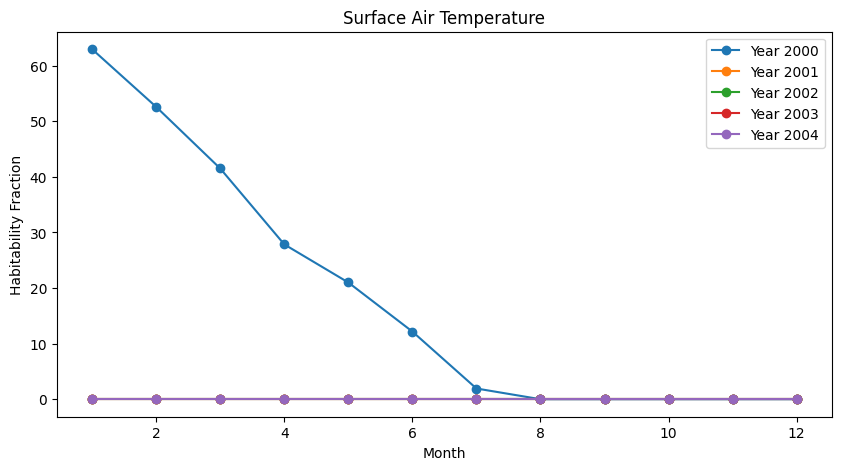

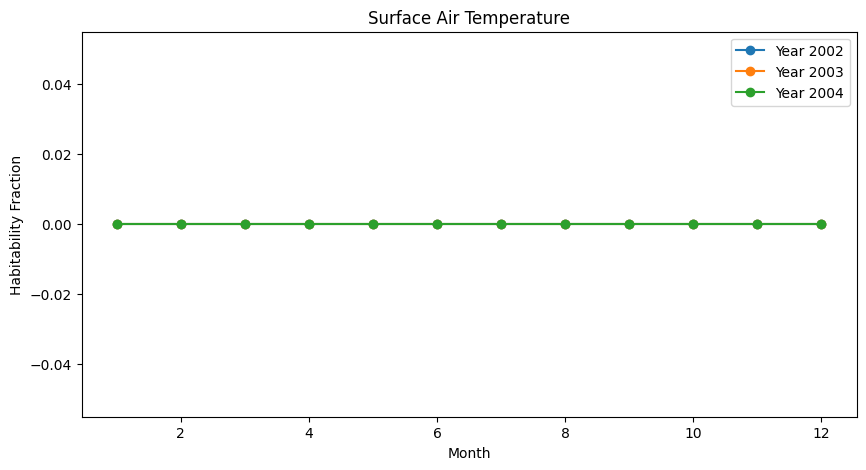

In [5]:
fig = plt.figure(figsize=(10, 5))
for yr_dict in results_hab:
    year = yr_dict["year"]
    month = yr_dict["data"]["month"]
    st = yr_dict["data"]["st_tot"]
    plt.plot(month, st, label=f"Year {year}", marker='o')

plt.xlabel("Month")
plt.title("Soil Temperature")
plt.ylabel("Habitability Fraction")
plt.legend()
plt.show()

fig = plt.figure(figsize=(10, 5))
for yr_dict in results_hab[2:]:
    year = yr_dict["year"]
    month = yr_dict["data"]["month"]
    st = yr_dict["data"]["st_tot"]
    plt.plot(month, st, label=f"Year {year}", marker='o')

plt.xlabel("Month")
plt.title("Soil Temperature")
plt.ylabel("Habitability Fraction")
plt.legend()
plt.show()

fig = plt.figure(figsize=(10, 5))
for yr_dict in results_hab[2:]:
    year = yr_dict["year"]
    month = yr_dict["data"]["month"]
    st = yr_dict["data"]["st_nhem"]
    plt.plot(month, st, label=f"Year {year}", marker='o')

plt.xlabel("Month")
plt.title("Soil Temperature Northern Hemisphere")
plt.ylabel("Habitability Fraction")
plt.legend()
plt.show()

fig = plt.figure(figsize=(10, 5))
for yr_dict in results_hab[2:]:
    year = yr_dict["year"]
    month = yr_dict["data"]["month"]
    st = yr_dict["data"]["st_shem"]
    plt.plot(month, st, label=f"Year {year}", marker='o')

plt.xlabel("Month")
plt.title("Soil Temperature Southern Hemisphere")
plt.ylabel("Habitability Fraction")
plt.legend()
plt.show()

fig = plt.figure(figsize=(10, 5))
for yr_dict in results_hab:
    year = yr_dict["year"]
    month = yr_dict["data"]["month"]
    sm = yr_dict["data"]["sm_tot"]
    plt.plot(month, sm, label=f"Year {year}", marker='o')

plt.xlabel("Month")
plt.title("Soil Moisture")
plt.ylabel("Habitability Fraction")
plt.legend()
plt.show()

fig = plt.figure(figsize=(10, 5))
for yr_dict in results_hab:
    year = yr_dict["year"]
    month = yr_dict["data"]["month"]
    tsurf = yr_dict["data"]["tsurf_tot"]
    plt.plot(month, tsurf, label=f"Year {year}", marker='o')

plt.xlabel("Month")
plt.title("Surface Air Temperature")
plt.ylabel("Habitability Fraction")
plt.legend()
plt.show()

fig = plt.figure(figsize=(10, 5))
for yr_dict in results_hab[2:]:
    year = yr_dict["year"]
    month = yr_dict["data"]["month"]
    tsurf = yr_dict["data"]["tsurf_tot"]
    plt.plot(month, tsurf, label=f"Year {year}", marker='o')

plt.xlabel("Month")
plt.title("Surface Air Temperature")
plt.ylabel("Habitability Fraction")
plt.legend()
plt.show()

We can see habitability stabilises in year 2, so now look at the data over the course of the 3rd year

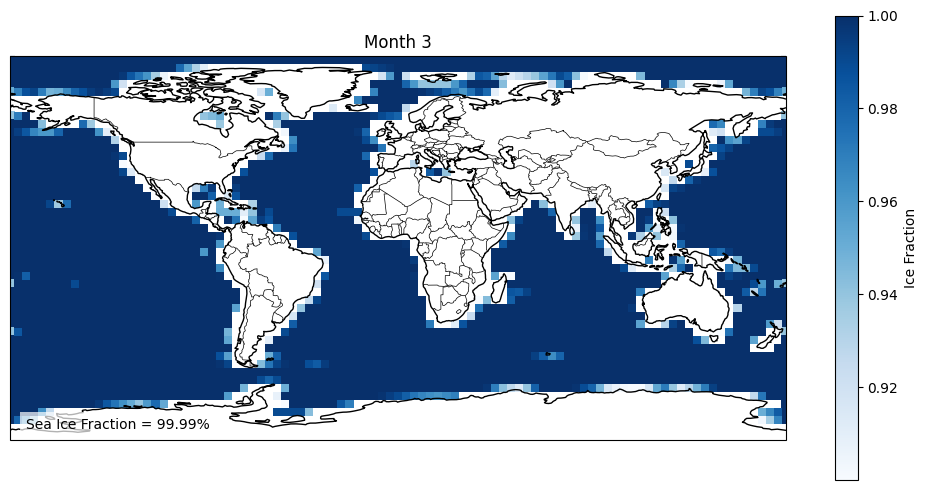

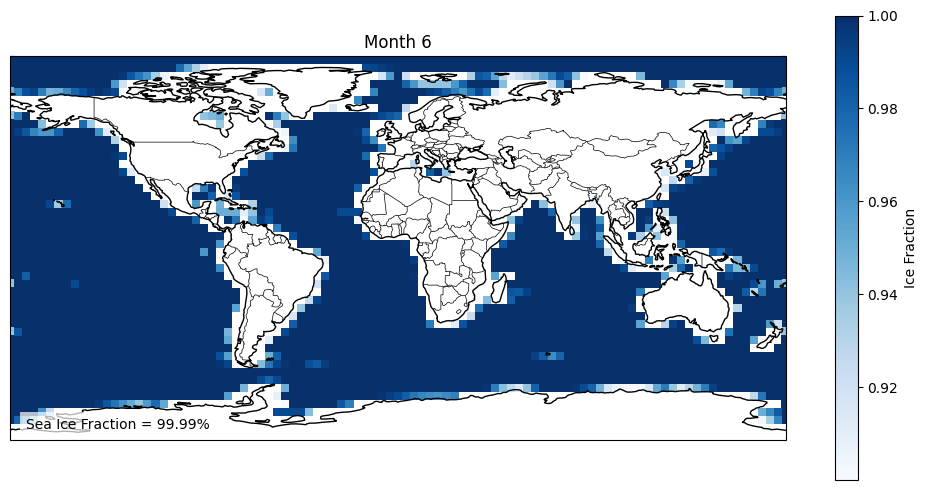

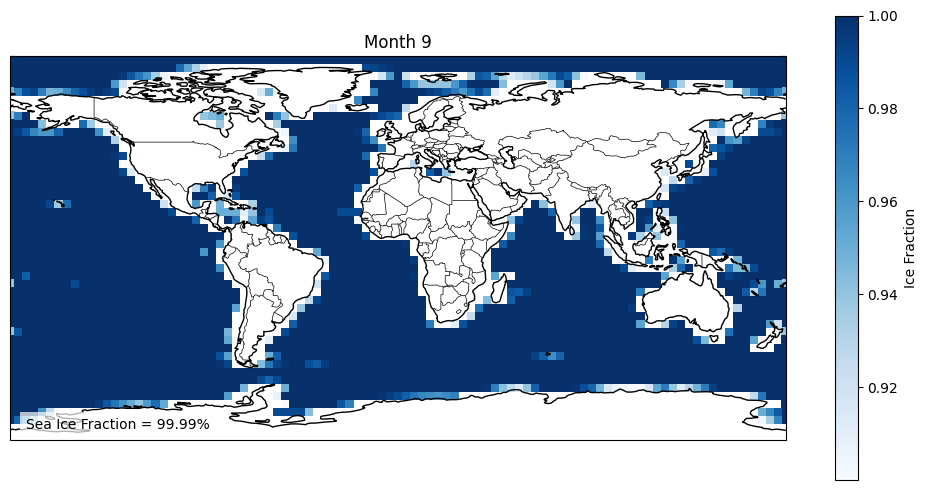

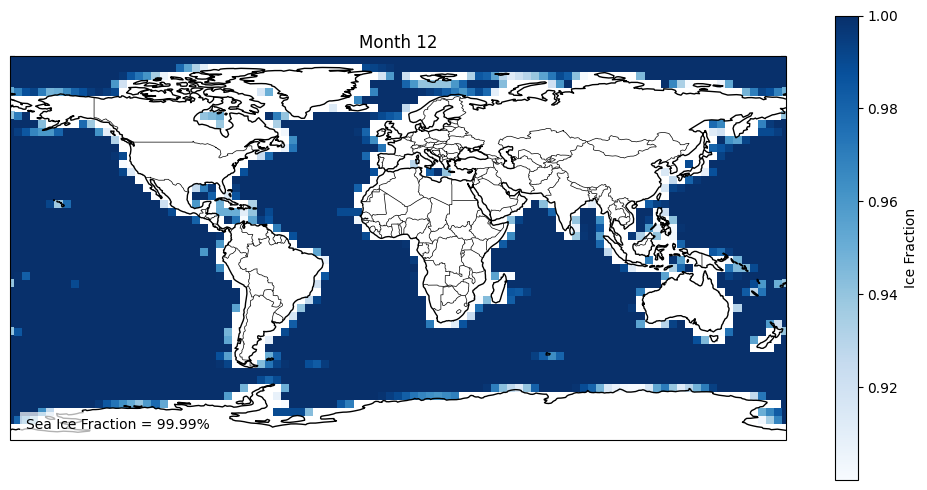

In [6]:
ds_crop = ds.sel(time=slice("2002-01-01", "2003-01-01"))
grouped_data = ds_crop.groupby("time.month")

months_to_keep = [3,6,9,12]
for month, month_ds in grouped_data:
    if month in months_to_keep:

        # Ice data
        ice_frac = SeaIceCalc.ice_frac(month_ds)[0]
        ice_dist = SeaIceCalc.ice_frac(month_ds)[1]

        # Land-sea mask
        lsm = month_ds["lsm"]

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        ice_dist.where(lsm<=0.1).plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={"label": "Ice Fraction"},
            cmap="Blues"
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"Sea Ice Fraction = {ice_frac:.2f}%",
            transform=ax.transAxes,
            ha="left", va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        plt.title(f"Month {month}")
    
        plt.tight_layout() 

Make a global plot every 3 months to see what sea ice, sst, precipitation, temperature is doing
Also make timeseries for each parameter in each hemisphere to see what changes

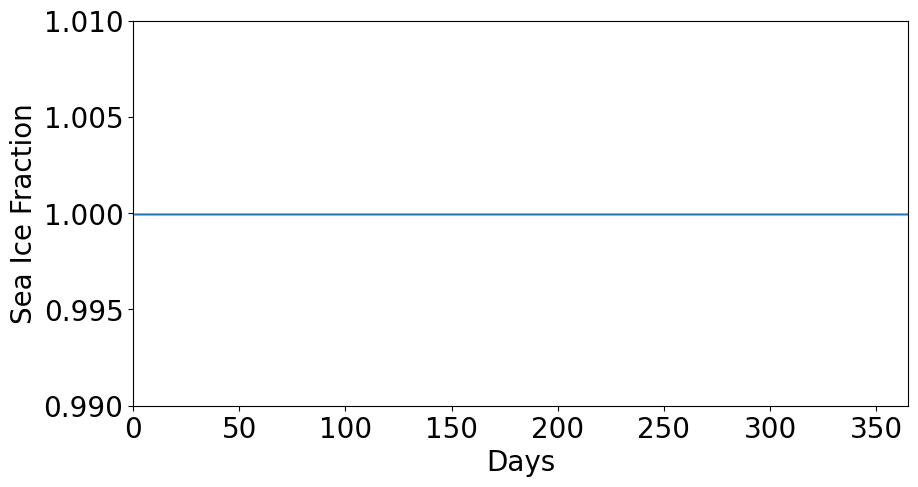

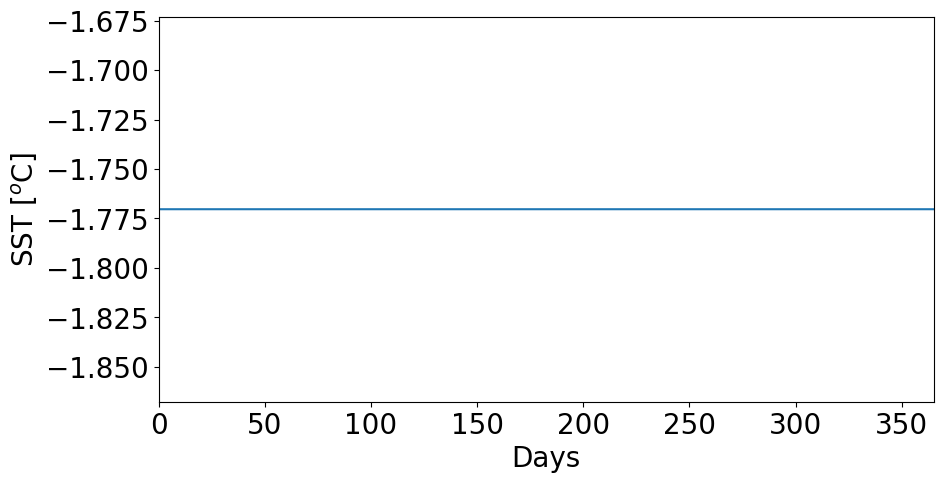

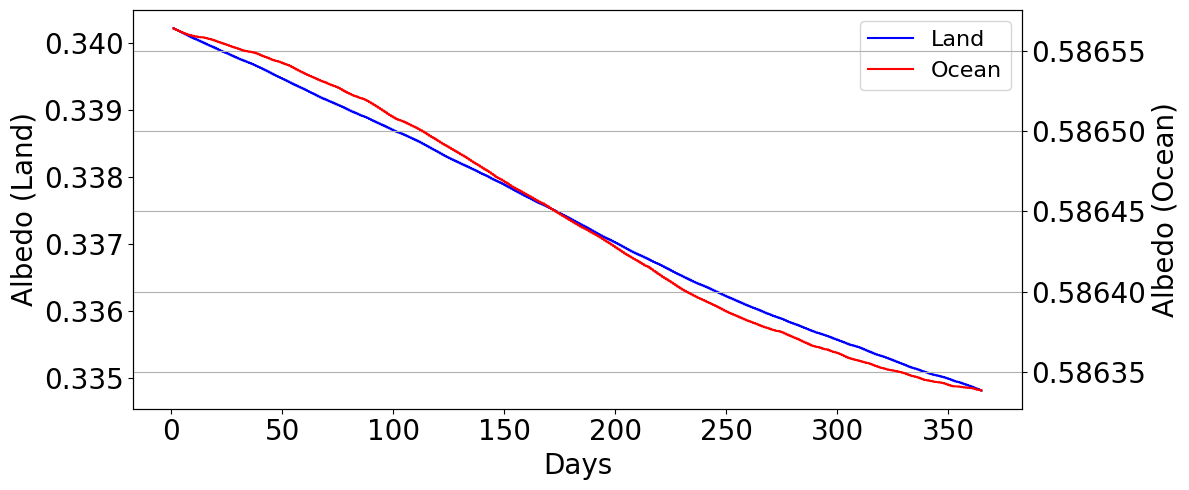

In [53]:
from timeseries_calc import OceanParam, WholeGlobeParam, LandParam, SeaIce

ds_crop = ds.sel(time=slice("2002-01-01", "2002-12-31"))

ice_concentration = SeaIce.sic_timeseries(ds_crop["sic"], ds_crop["lsm"])
albedo_land = LandParam.landparam_timeseries(ds_crop["albedo"], ds_crop["lsm"])
albedo_ocean = OceanParam.oceanparam_timeseries(ds_crop["albedo"], ds_crop["lsm"])
times = ds_crop.time.dt.dayofyear.values

fig = plt.figure(figsize=(10, 5))
plt.plot(times, ice_concentration)
plt.xlabel("Days", size=20)
plt.ylabel("Sea Ice Fraction", size=20)
plt.xticks(size=20)
plt.ylim(0.99,1.01)
plt.xlim(0,365)
plt.yticks([0.99, 0.995, 1.0, 1.005, 1.01],size=20)
plt.show()

sst = OceanParam.oceanparam_timeseries(ds_crop["sst"], ds_crop["lsm"])
fig = plt.figure(figsize=(10, 5))
plt.plot(times, sst)
plt.xlabel("Days", size=20)
plt.ylabel("SST [$^o$C]", size=20)
plt.xticks(size=20)
# plt.ylim(0.99,1.01)
plt.xlim(0,365)
plt.yticks(size=20)
plt.show()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(times, albedo_land, color='blue', label="Land")
ax1.set_xlabel("Days", size=20)
ax1.set_ylabel("Albedo (Land)", size=20)
# ax1.set_yticks([18.5, 19, 19.5, 20, 20.5])
ax1.tick_params(axis='x', labelsize=20)
ax1.tick_params(axis='y', labelsize=20)

ax2 = ax1.twinx()
ax2.plot(times, albedo_ocean, color='red', label="Ocean")
# ax2.set_yticks([12.4, 12.5, 12.6, 12.7, 12.8, 12.9])
ax2.set_ylabel("Albedo (Ocean)", size=20)
ax2.tick_params(axis='y', labelsize=20)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=16)

plt.grid(True)
plt.tight_layout()
plt.show()



In [8]:
print(ds_crop.variables)

Frozen({'time': <xarray.IndexVariable 'time' (time: 1460)> Size: 12kB
array(['2002-01-01T00:00:00.000000000', '2002-01-01T06:00:00.000000000',
       '2002-01-01T12:00:00.000000000', ..., '2002-12-31T06:00:00.000000000',
       '2002-12-31T12:00:00.000000000', '2002-12-31T18:00:00.000000000'],
      dtype='datetime64[ns]')
Attributes:
    long_name:      time
    standard_name:  time, 'lon': <xarray.IndexVariable 'lon' (lon: 96)> Size: 768B
array([  0.  ,   3.75,   7.5 ,  11.25,  15.  ,  18.75,  22.5 ,  26.25,  30.  ,
        33.75,  37.5 ,  41.25,  45.  ,  48.75,  52.5 ,  56.25,  60.  ,  63.75,
        67.5 ,  71.25,  75.  ,  78.75,  82.5 ,  86.25,  90.  ,  93.75,  97.5 ,
       101.25, 105.  , 108.75, 112.5 , 116.25, 120.  , 123.75, 127.5 , 131.25,
       135.  , 138.75, 142.5 , 146.25, 150.  , 153.75, 157.5 , 161.25, 165.  ,
       168.75, 172.5 , 176.25, 180.  , 183.75, 187.5 , 191.25, 195.  , 198.75,
       202.5 , 206.25, 210.  , 213.75, 217.5 , 221.25, 225.  , 228.75, 232.5 ,
  

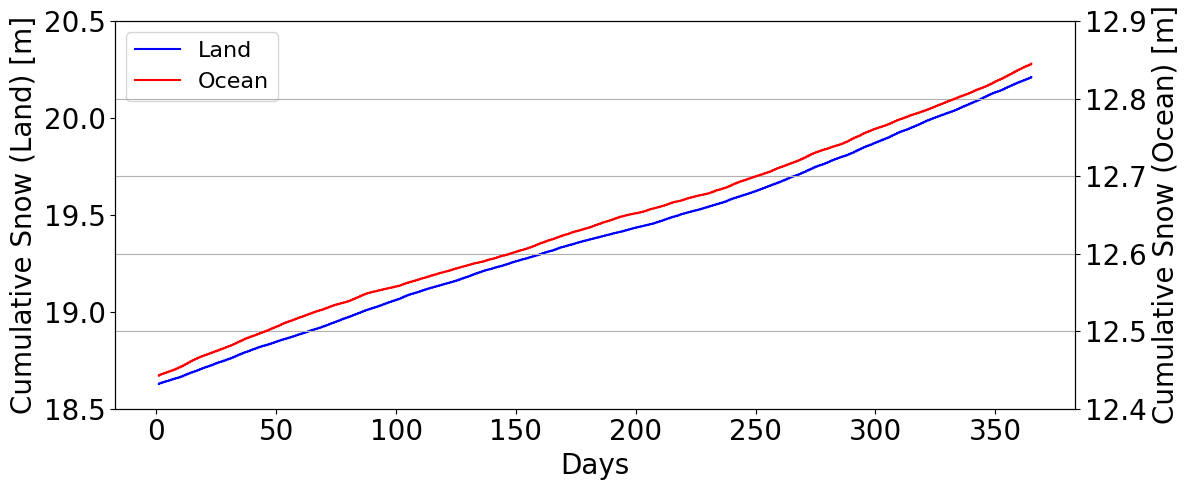

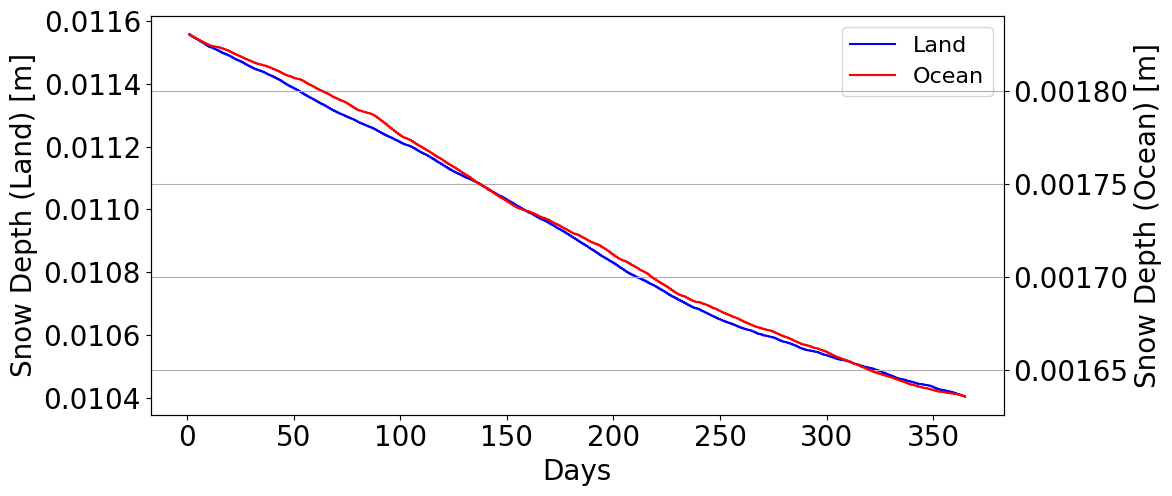

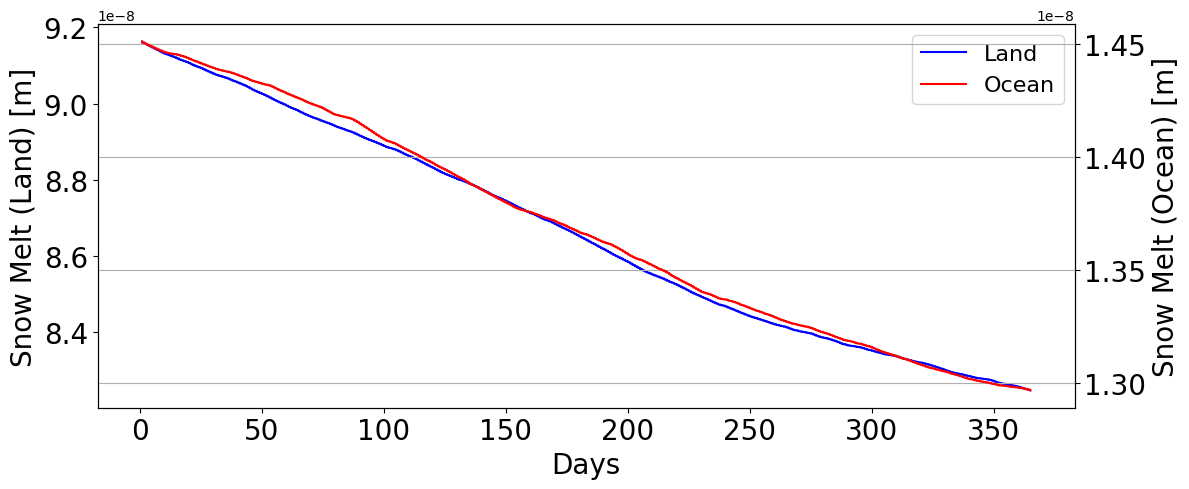

In [9]:
cumul_snow_land = LandParam.landparam_timeseries(ds_crop["snow_cond"],ds_crop["lsm"])
cumul_snow_ocean = OceanParam.oceanparam_timeseries(ds_crop["snow_cond"],ds_crop["lsm"])

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(times, cumul_snow_land, color='blue', label="Land")
ax1.set_xlabel("Days", size=20)
ax1.set_ylabel("Cumulative Snow (Land) [m]", size=20)
ax1.set_yticks([18.5, 19, 19.5, 20, 20.5])
ax1.tick_params(axis='x', labelsize=20)
ax1.tick_params(axis='y', labelsize=20)

ax2 = ax1.twinx()
ax2.plot(times, cumul_snow_ocean, color='red', label="Ocean")
ax2.set_yticks([12.4, 12.5, 12.6, 12.7, 12.8, 12.9])
ax2.set_ylabel("Cumulative Snow (Ocean) [m]", size=20)
ax2.tick_params(axis='y', labelsize=20)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=16)

plt.grid(True)
plt.tight_layout()
plt.show()

snow_depth_land = LandParam.landparam_timeseries(ds_crop["sd"],ds_crop["lsm"])
snow_depth_ocean = OceanParam.oceanparam_timeseries(ds_crop["sd"],ds_crop["lsm"])

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(times, snow_depth_land, color='blue', label="Land")
ax1.set_xlabel("Days", size=20)
ax1.set_ylabel("Snow Depth (Land) [m]", size=20)
# ax1.set_yticks([18.5, 19, 19.5, 20, 20.5])
ax1.tick_params(axis='x', labelsize=20)
ax1.tick_params(axis='y', labelsize=20)

ax2 = ax1.twinx()
ax2.plot(times, snow_depth_ocean, color='red', label="Ocean")
# ax2.set_yticks([12.4, 12.5, 12.6, 12.7, 12.8, 12.9])
ax2.set_ylabel("Snow Depth (Ocean) [m]", size=20)
ax2.tick_params(axis='y', labelsize=20)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=16)

plt.grid(True)
plt.tight_layout()
plt.show()

snow_melt_land = LandParam.landparam_timeseries(ds_crop["smelt"],ds_crop["lsm"])
snow_melt_ocean = OceanParam.oceanparam_timeseries(ds_crop["smelt"],ds_crop["lsm"])

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(times, snow_melt_land, color='blue', label="Land")
ax1.set_xlabel("Days", size=20)
ax1.set_ylabel("Snow Melt (Land) [m]", size=20)
# ax1.set_yticks([18.5, 19, 19.5, 20, 20.5])
ax1.tick_params(axis='x', labelsize=20)
ax1.tick_params(axis='y', labelsize=20)

ax2 = ax1.twinx()
ax2.plot(times, snow_melt_ocean, color='red', label="Ocean")
# ax2.set_yticks([12.4, 12.5, 12.6, 12.7, 12.8, 12.9])
ax2.set_ylabel("Snow Melt (Ocean) [m]", size=20)
ax2.tick_params(axis='y', labelsize=20)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=16)

plt.grid(True)
plt.tight_layout()
plt.show()

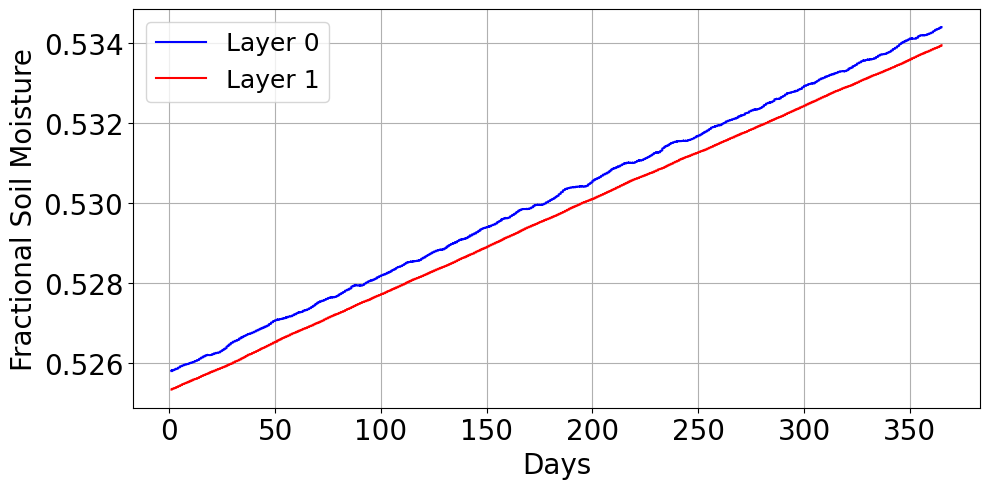

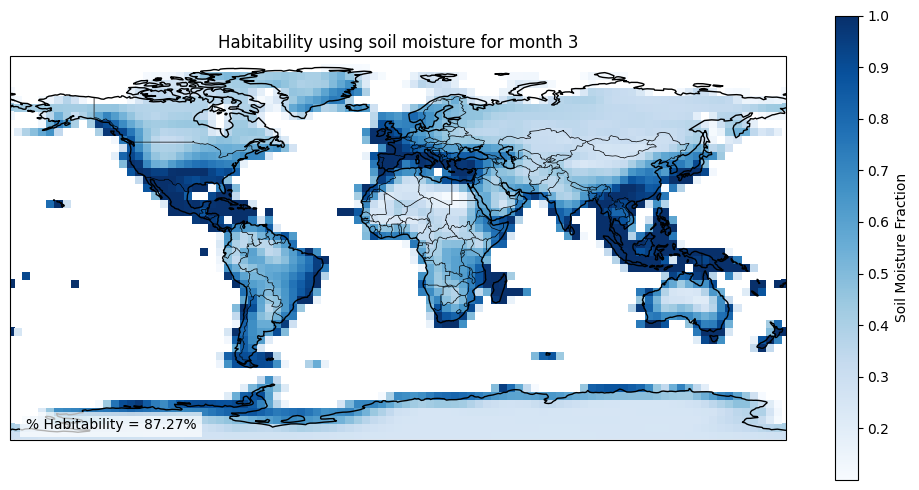

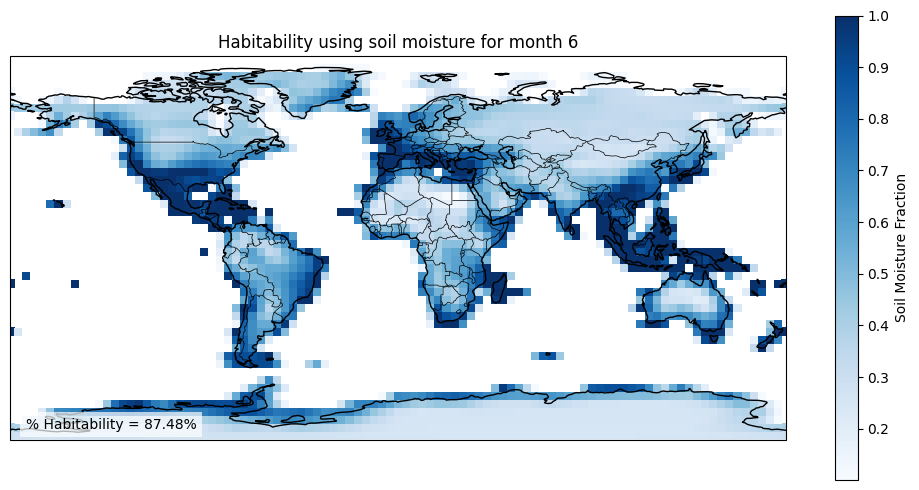

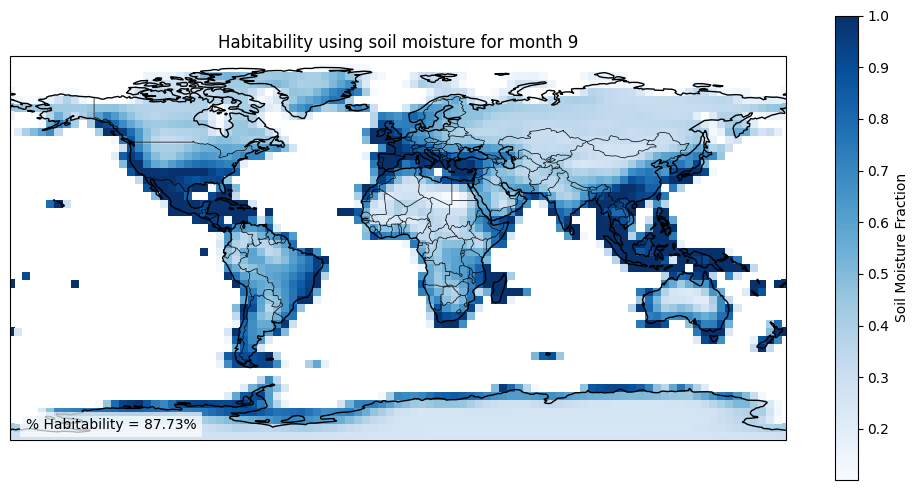

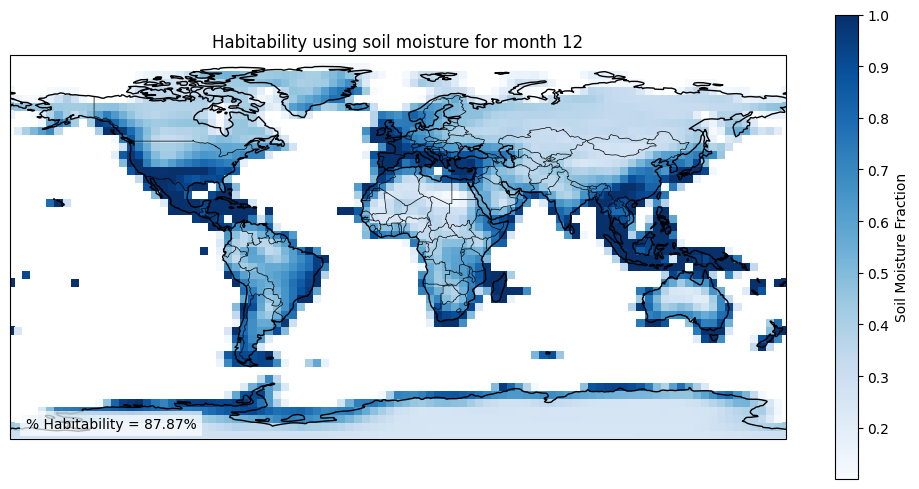

In [10]:
sm_l0 = LandParam.landparam_timeseries(ds_crop["sm"].isel(soil_layer=0),ds_crop["lsm"])
sm_l1 = LandParam.landparam_timeseries(ds_crop["sm"].isel(soil_layer=1),ds_crop["lsm"])

fig = plt.figure(figsize=(10, 5))
plt.plot(times, sm_l0, color='blue', label="Layer 0")
plt.plot(times, sm_l1, color='red', label="Layer 1")
plt.ylabel("Fractional Soil Moisture", size=20)
plt.xlabel('Days', size=20)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()

months_to_keep = [3,6,9,12]
for month, month_ds in grouped_data:
    if month in months_to_keep:

        # Soil Moisture
        fraction = Habitability.fraction(month_ds, "sm")[0]
        mean_plot = Habitability.fraction(month_ds, "sm")[1]
        habitable_plot = Habitability.fraction(month_ds, "sm")[2]

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        mean_plot.where(habitable_plot).plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={"label": "Soil Moisture Fraction"},
            cmap="Blues"
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"% Habitability = {fraction:.2f}%",
            transform=ax.transAxes,
            ha="left", va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        plt.title(f"Habitability using soil moisture for month {month}")
    
        plt.tight_layout()

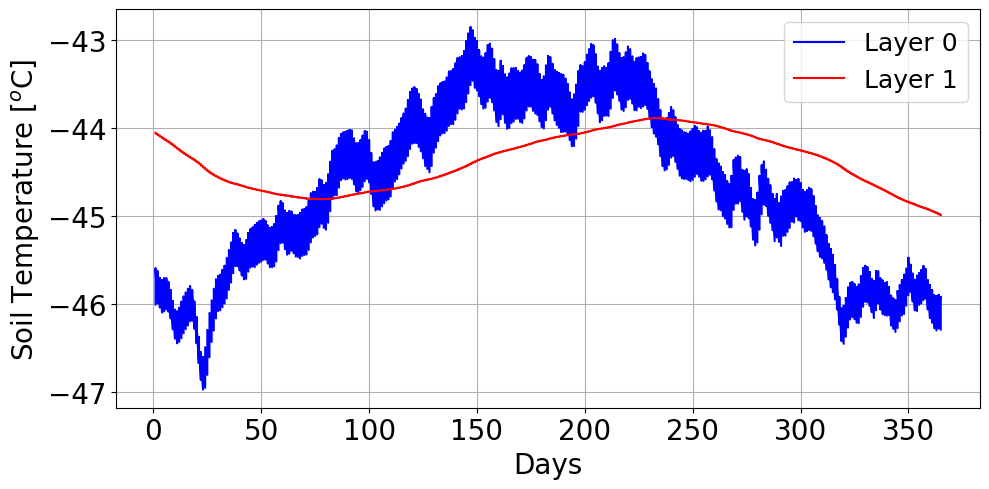

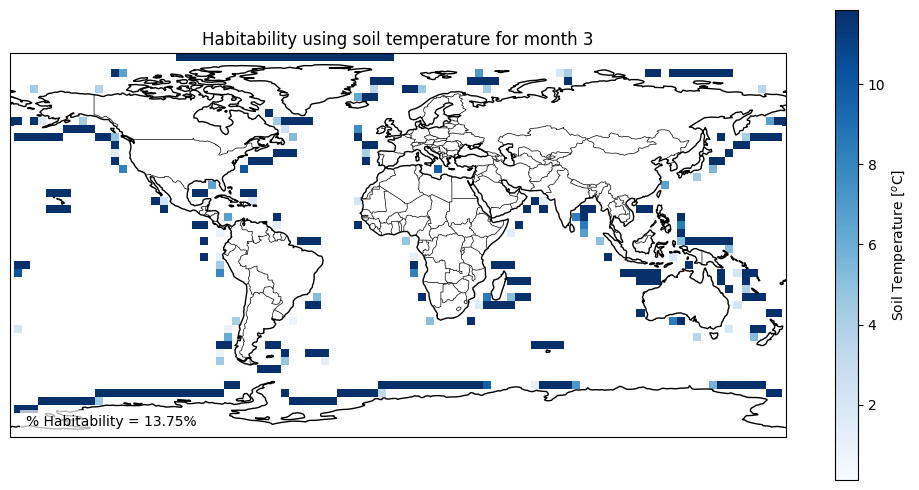

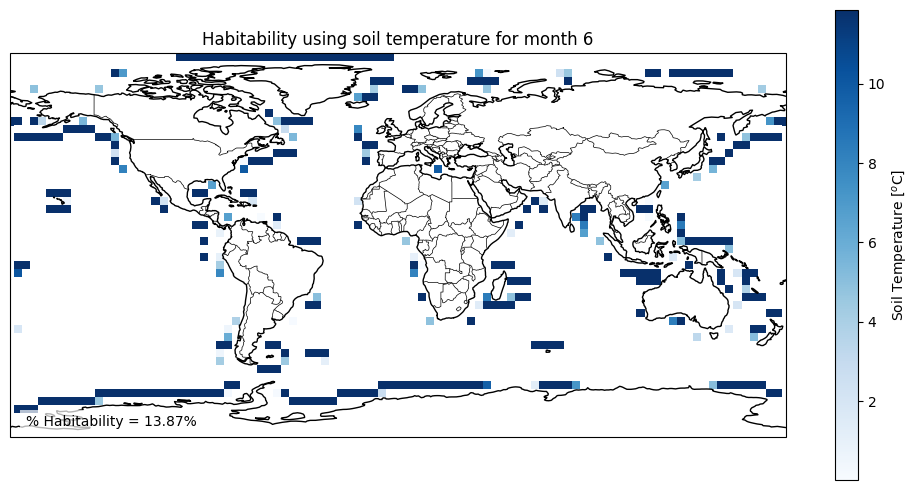

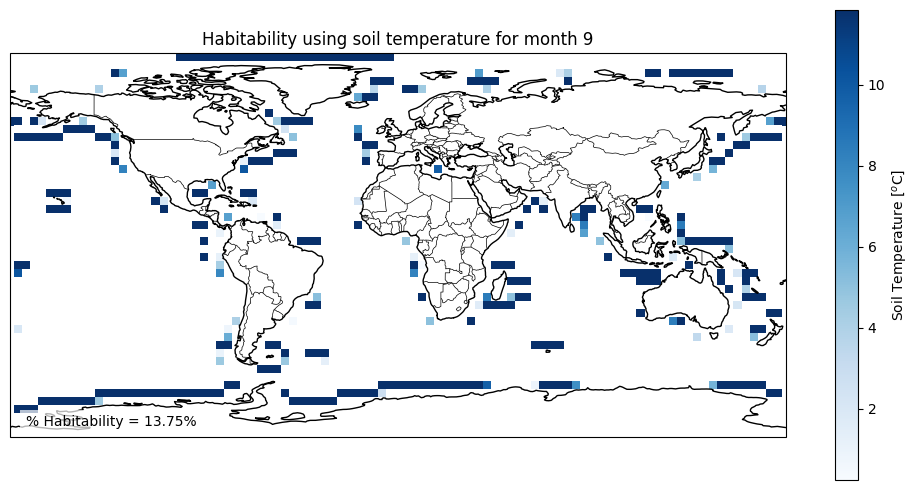

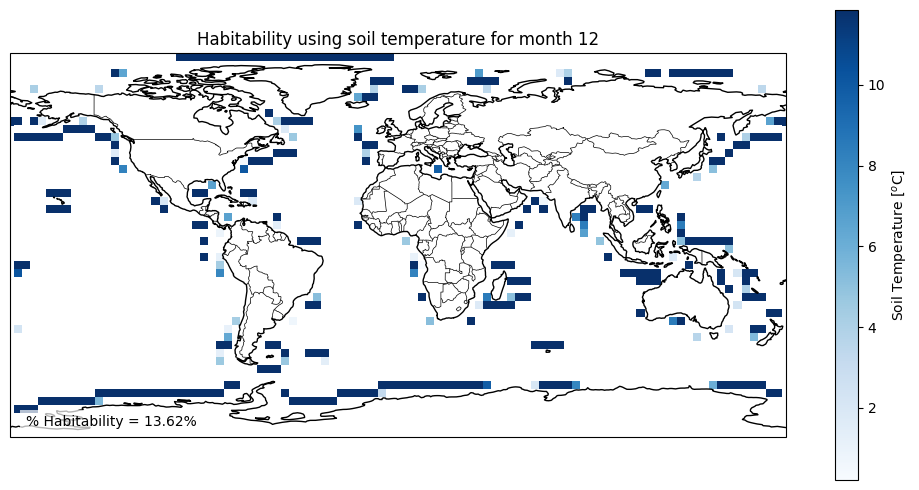

In [11]:
st_l0 = LandParam.landparam_timeseries(ds_crop["st"].isel(soil_layer=0),ds_crop["lsm"])
st_l1 = LandParam.landparam_timeseries(ds_crop["st"].isel(soil_layer=1),ds_crop["lsm"])

fig = plt.figure(figsize=(10, 5))
plt.plot(times, st_l0, color='blue', label="Layer 0")
plt.plot(times, st_l1, color='red', label="Layer 1")
plt.ylabel("Soil Temperature [$^o$C]", size=20)
plt.xlabel('Days', size=20)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()

months_to_keep = [3,6,9,12]
for month, month_ds in grouped_data:
    if month in months_to_keep:

        # Soil Moisture
        fraction = Habitability.fraction(month_ds, "st")[0]
        mean_plot = Habitability.fraction(month_ds, "st")[1]
        habitable_plot = Habitability.fraction(month_ds, "st")[2]

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        mean_plot.where(habitable_plot).plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={"label": "Soil Temperature [$^o$C]"},
            cmap="Blues"
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"% Habitability = {fraction:.2f}%",
            transform=ax.transAxes,
            ha="left", va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        plt.title(f"Habitability using soil temperature for month {month}")
    
        plt.tight_layout()

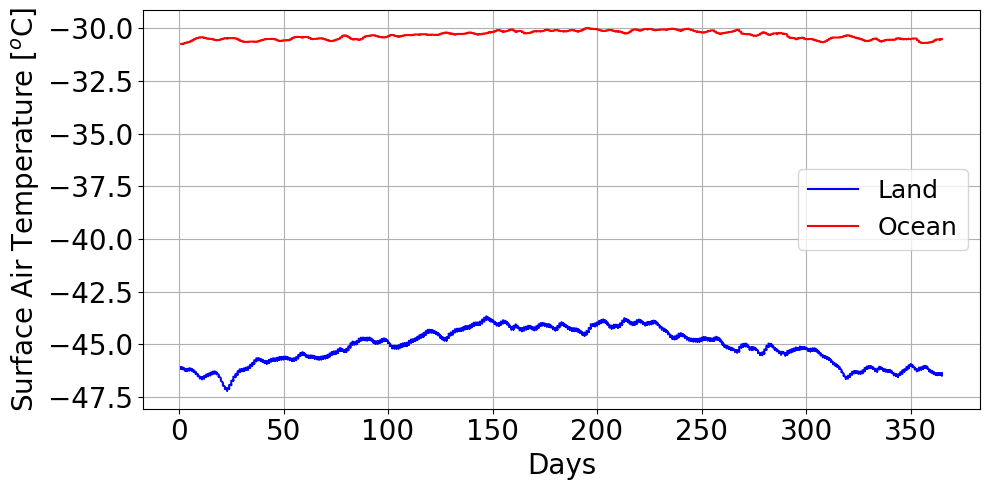

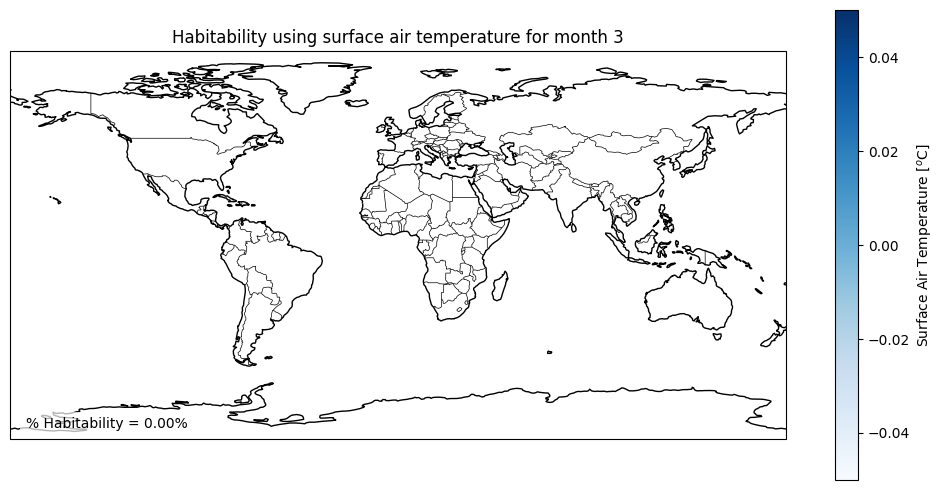

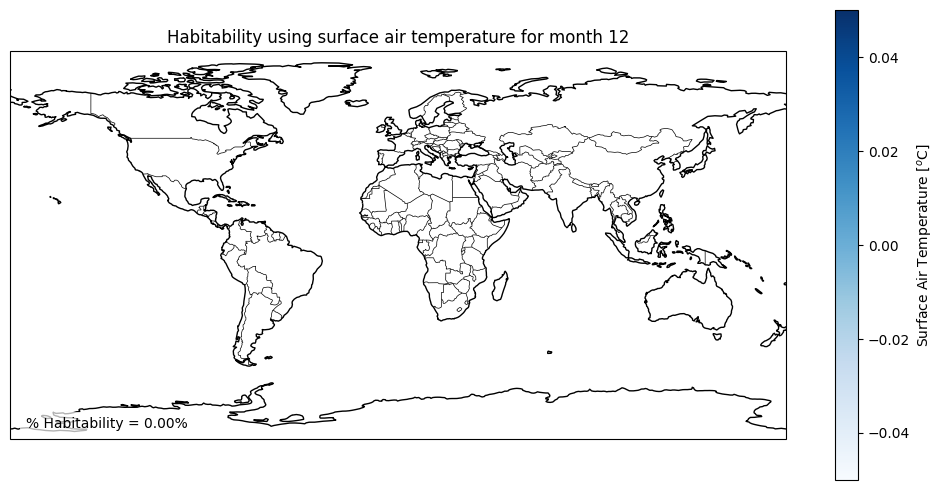

In [12]:
ts_l = LandParam.landparam_timeseries(ds_crop["tsurf"],ds_crop["lsm"])
ts_o = OceanParam.oceanparam_timeseries(ds_crop["tsurf"],ds_crop["lsm"])

fig = plt.figure(figsize=(10, 5))
plt.plot(times, ts_l, color='blue', label="Land")
plt.plot(times, ts_o, color='red', label="Ocean")
plt.ylabel("Surface Air Temperature [$^o$C]", size=20)
plt.xlabel('Days', size=20)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()

months_to_keep = [3,12]
for month, month_ds in grouped_data:
    if month in months_to_keep:

        # Soil Moisture
        fraction = Habitability.fraction(month_ds, "tsurf")[0]
        mean_plot = Habitability.fraction(month_ds, "tsurf")[1]
        habitable_plot = Habitability.fraction(month_ds, "tsurf")[2]

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        mean_plot.where(habitable_plot).plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={"label": "Surface Air Temperature [$^o$C]"},
            cmap="Blues"
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"% Habitability = {fraction:.2f}%",
            transform=ax.transAxes,
            ha="left", va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        plt.title(f"Habitability using surface air temperature for month {month}")
    
        plt.tight_layout()

Have seen surface air and soil temperature is very low:

- Seasonality still observed in soil temperature
- Soil moisture much lower

Now check:
- Precipitation (low precipitation could be why soil moisture is low, could be why snow depth is decreasing)
- Cloud cover (could be why albedo/snow is slowly decreasing)
- Radiation budget (small imbalance can melt snow)


In [13]:
print(ds_crop.variables)

Frozen({'time': <xarray.IndexVariable 'time' (time: 1460)> Size: 12kB
array(['2002-01-01T00:00:00.000000000', '2002-01-01T06:00:00.000000000',
       '2002-01-01T12:00:00.000000000', ..., '2002-12-31T06:00:00.000000000',
       '2002-12-31T12:00:00.000000000', '2002-12-31T18:00:00.000000000'],
      dtype='datetime64[ns]')
Attributes:
    long_name:      time
    standard_name:  time, 'lon': <xarray.IndexVariable 'lon' (lon: 96)> Size: 768B
array([  0.  ,   3.75,   7.5 ,  11.25,  15.  ,  18.75,  22.5 ,  26.25,  30.  ,
        33.75,  37.5 ,  41.25,  45.  ,  48.75,  52.5 ,  56.25,  60.  ,  63.75,
        67.5 ,  71.25,  75.  ,  78.75,  82.5 ,  86.25,  90.  ,  93.75,  97.5 ,
       101.25, 105.  , 108.75, 112.5 , 116.25, 120.  , 123.75, 127.5 , 131.25,
       135.  , 138.75, 142.5 , 146.25, 150.  , 153.75, 157.5 , 161.25, 165.  ,
       168.75, 172.5 , 176.25, 180.  , 183.75, 187.5 , 191.25, 195.  , 198.75,
       202.5 , 206.25, 210.  , 213.75, 217.5 , 221.25, 225.  , 228.75, 232.5 ,
  

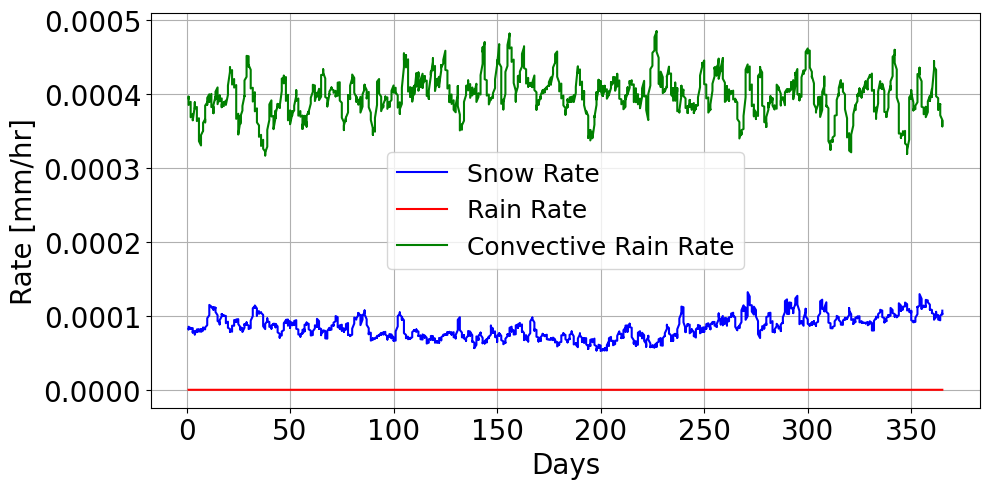

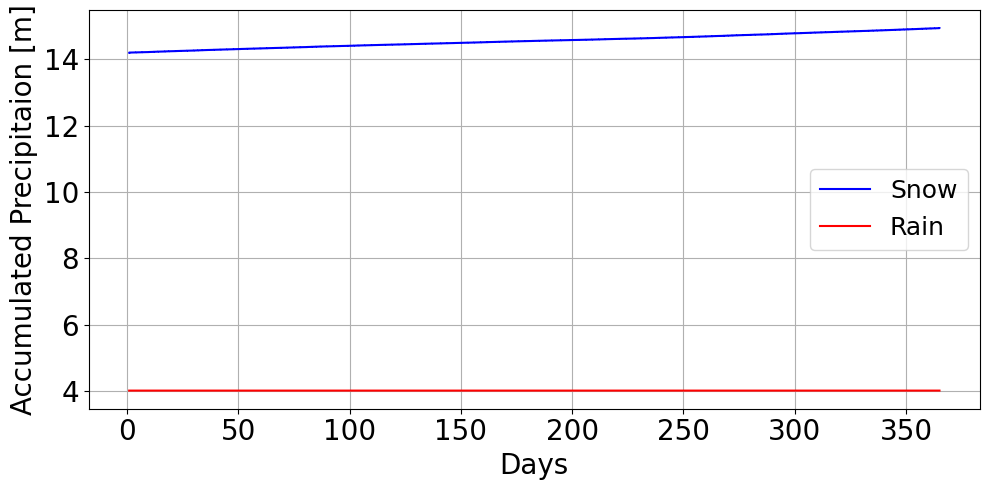

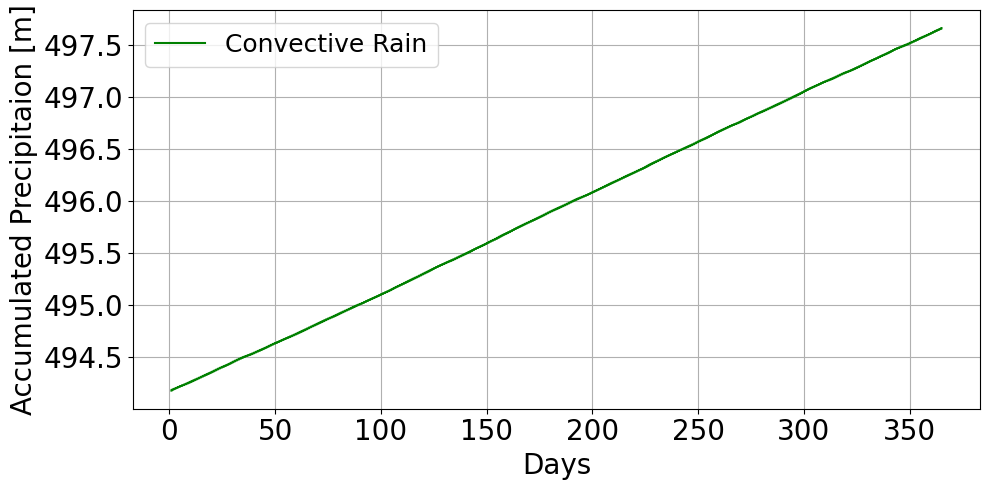

In [28]:
# Snow melt (smelt), snow depth (sd), accumulated snow (snow_cond), snow rate (snow_cond_rate)
# convective rain rate (rain_conv_rate), large-scale rain rate (rain_cond_rate), accumulated covective rain (rain_conv), accumulated large-scale rain (rain_cond)

snow_rate = WholeGlobeParam.globalparam_timeseries(ds_crop["snow_cond_rate"])
rain_rate = WholeGlobeParam.globalparam_timeseries(ds_crop["rain_cond_rate"])
convective_rain_rate = WholeGlobeParam.globalparam_timeseries(ds_crop["rain_conv_rate"])

fig = plt.figure(figsize=(10, 5))
plt.plot(times, snow_rate, color='blue', label="Snow Rate")
plt.plot(times, rain_rate, color='red', label="Rain Rate")
plt.plot(times, convective_rain_rate, color='green', label="Convective Rain Rate")
plt.ylabel("Rate [mm/hr]", size=20)
plt.xlabel('Days', size=20)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()

snow = WholeGlobeParam.globalparam_timeseries(ds_crop["snow_cond"])
rain = WholeGlobeParam.globalparam_timeseries(ds_crop["rain_cond"])
convective_rain = WholeGlobeParam.globalparam_timeseries(ds_crop["rain_conv"])

fig = plt.figure(figsize=(10, 5))
plt.plot(times, snow, color='blue', label="Snow")
plt.plot(times, rain, color='red', label="Rain")
plt.ylabel("Accumulated Precipitaion [m]", size=20)
plt.xlabel('Days', size=20)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(10, 5))
plt.plot(times, convective_rain, color='green', label="Convective Rain")
plt.ylabel("Accumulated Precipitaion [m]", size=20)
plt.xlabel('Days', size=20)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()


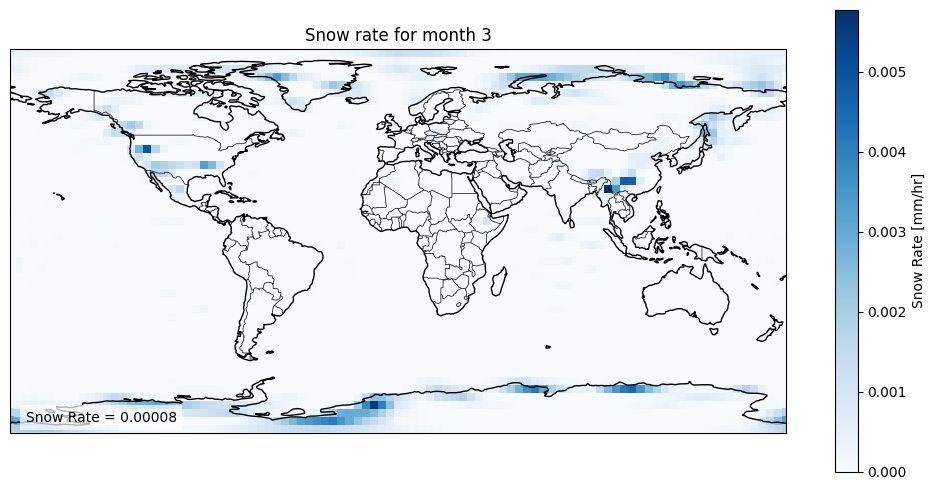

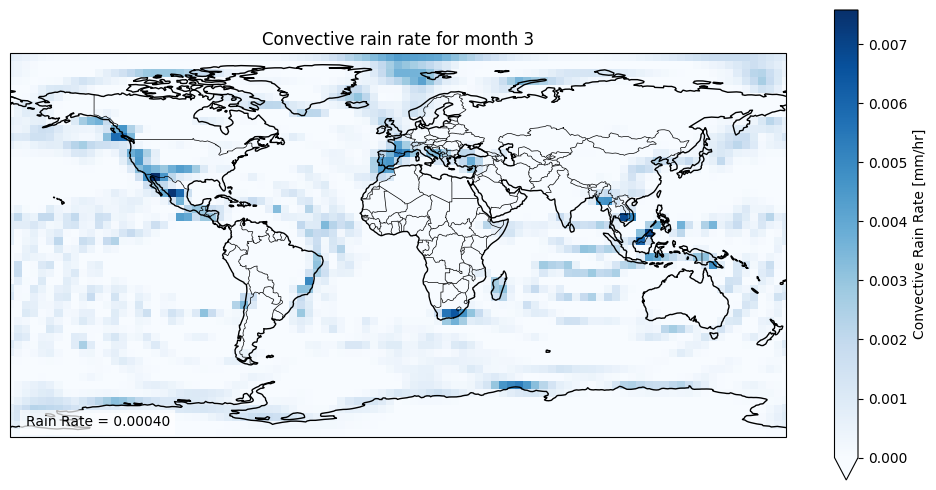

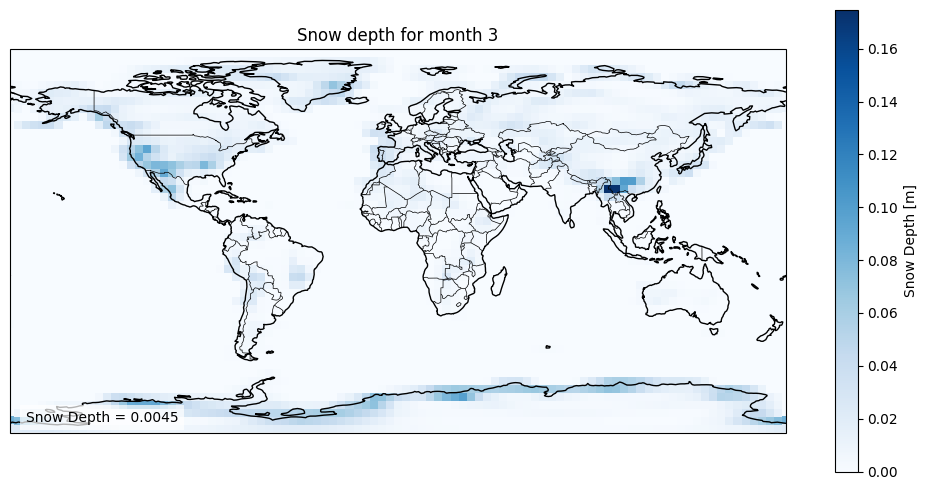

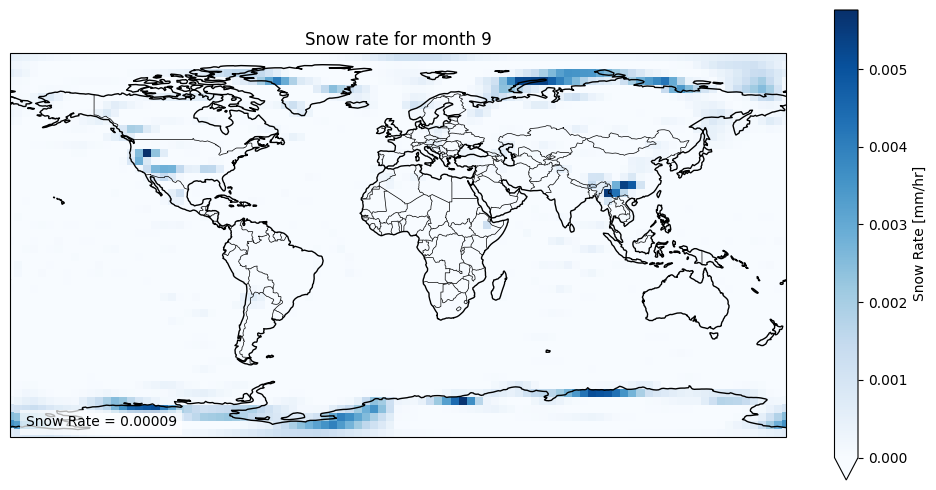

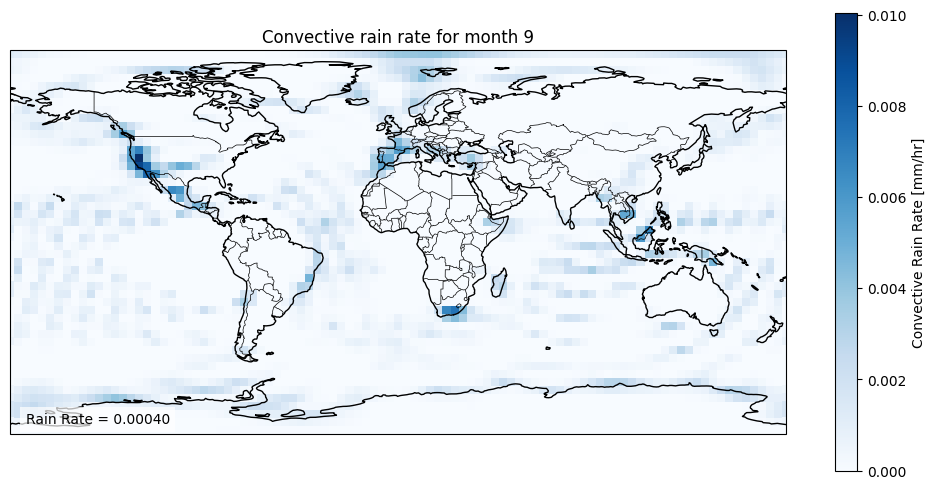

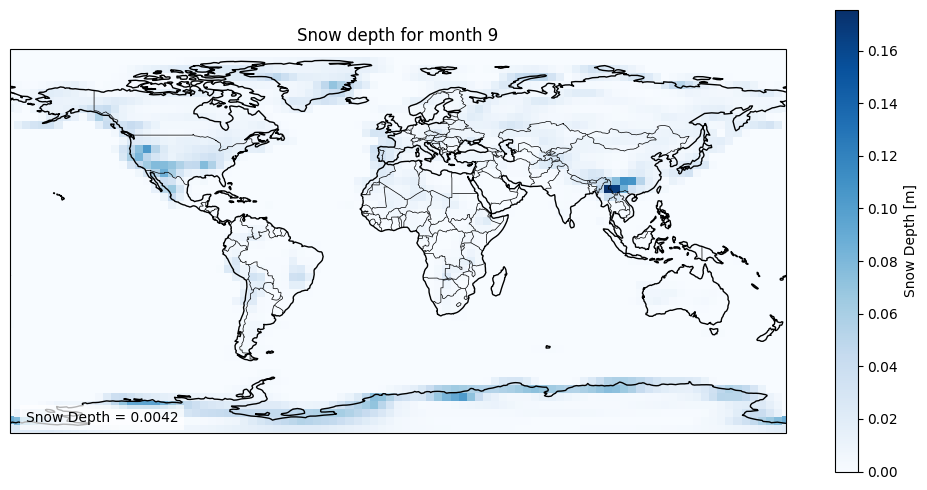

In [64]:
# Check where its snowing vs convectively raining

months_to_keep = [3,9]
for month, month_ds in grouped_data:
    if month in months_to_keep:

        snow_rate = month_ds["snow_cond_rate"]
        snow_mean = snow_rate.mean("time")
  
        # Weights
        lat = snow_mean.lat
        weights = np.cos(np.deg2rad(lat))
        weights = weights.where(np.isfinite(weights), 0)
        weights_2d, _ = xr.broadcast(weights, snow_mean)

        # Area weighted fraction
        numerator_snow = (snow_mean * weights_2d).sum(dim=["lat", "lon"])
        denominator_snow = (weights_2d).sum(dim=["lat", "lon"])
        frac_snow = ( numerator_snow / denominator_snow )

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        snow_mean.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={"label": "Snow Rate [mm/hr]"},
            cmap="Blues",
            vmin=0
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"Snow Rate = {frac_snow:.5f}",
            transform=ax.transAxes,
            ha="left", va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        plt.title(f"Snow rate for month {month}")
        plt.tight_layout() 

        convrain_rate = month_ds["rain_conv_rate"]
        rain_mean = convrain_rate.mean("time")

        # Area weighted fraction
        numerator_rain = (rain_mean * weights_2d).sum(dim=["lat", "lon"])
        denominator_rain = (weights_2d).sum(dim=["lat", "lon"])
        frac_rain = ( numerator_rain / denominator_rain )

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        rain_mean.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={"label": "Convective Rain Rate [mm/hr]"},
            cmap="Blues",
            vmin=0
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"Rain Rate = {frac_rain:.5f}",
            transform=ax.transAxes,
            ha="left", va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        plt.title(f"Convective rain rate for month {month}")
        plt.tight_layout() 

        sd = month_ds["sd"]
        sd_mean = sd.mean("time")

        # Area weighted fraction
        numerator_sd = (sd_mean * weights_2d).sum(dim=["lat", "lon"])
        denominator_sd = (weights_2d).sum(dim=["lat", "lon"])
        frac_sd = ( numerator_sd / denominator_sd )

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        sd_mean.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={"label": "Snow Depth [m]"},
            cmap="Blues",
            vmin=0
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"Snow Depth = {frac_sd:.4f}",
            transform=ax.transAxes,
            ha="left", va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        plt.title(f"Snow depth for month {month}")
        plt.tight_layout() 

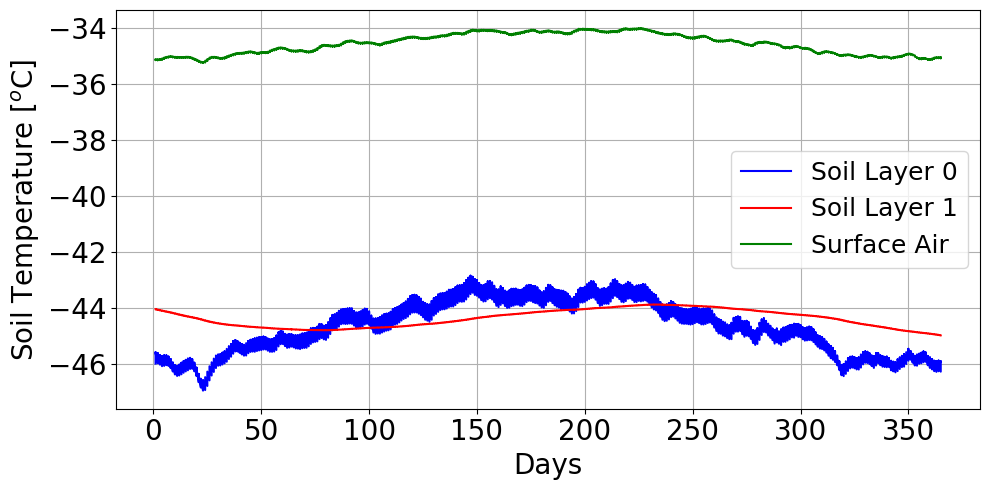

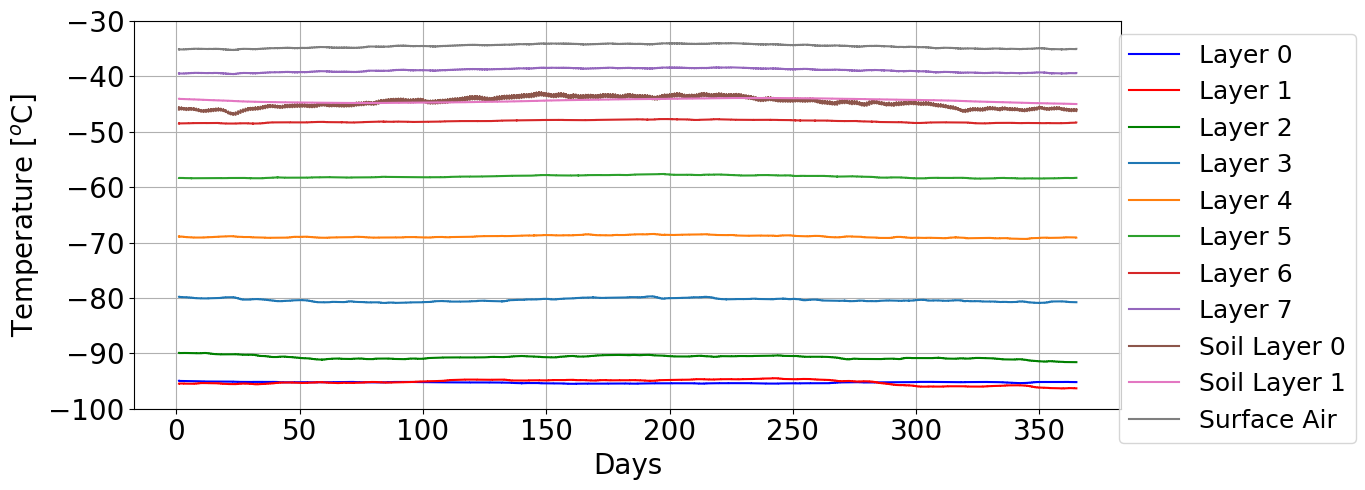

In [49]:
# Look at temperature in general (not habitability)

st_l0 = LandParam.landparam_timeseries(ds_crop["st"].isel(soil_layer=0),ds_crop["lsm"])
st_l1 = LandParam.landparam_timeseries(ds_crop["st"].isel(soil_layer=1),ds_crop["lsm"])
ts = WholeGlobeParam.globalparam_timeseries(ds_crop["tsurf"])

fig = plt.figure(figsize=(10, 5))
plt.plot(times, st_l0, color='blue', label="Soil Layer 0")
plt.plot(times, st_l1, color='red', label="Soil Layer 1")
plt.plot(times, ts, color='green', label="Surface Air")
plt.ylabel("Soil Temperature [$^o$C]", size=20)
plt.xlabel('Days', size=20)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()

t0 = WholeGlobeParam.globalparam_timeseries(ds_crop["temp"].isel(layer=0))
t1 = WholeGlobeParam.globalparam_timeseries(ds_crop["temp"].isel(layer=1))
t2 = WholeGlobeParam.globalparam_timeseries(ds_crop["temp"].isel(layer=2))
t3 = WholeGlobeParam.globalparam_timeseries(ds_crop["temp"].isel(layer=3))
t4 = WholeGlobeParam.globalparam_timeseries(ds_crop["temp"].isel(layer=4))
t5 = WholeGlobeParam.globalparam_timeseries(ds_crop["temp"].isel(layer=5))
t6 = WholeGlobeParam.globalparam_timeseries(ds_crop["temp"].isel(layer=6))
t7 = WholeGlobeParam.globalparam_timeseries(ds_crop["temp"].isel(layer=7))

fig = plt.figure(figsize=(14, 5))
plt.plot(times, t0, color='blue', label="Layer 0")
plt.plot(times, t1, color='red', label="Layer 1")
plt.plot(times, t2, color='green', label="Layer 2")
plt.plot(times, t3, label="Layer 3")
plt.plot(times, t4, label="Layer 4")
plt.plot(times, t5, label="Layer 5")
plt.plot(times, t6, label="Layer 6")
plt.plot(times, t7, label="Layer 7")
plt.plot(times, st_l0, label="Soil Layer 0")
plt.plot(times, st_l1, label="Soil Layer 1")
plt.plot(times, ts, label="Surface Air")
plt.ylabel("Temperature [$^o$C]", size=20)
plt.xlabel('Days', size=20)
plt.ylim(-100,-30)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18,  loc="upper right", bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.show()

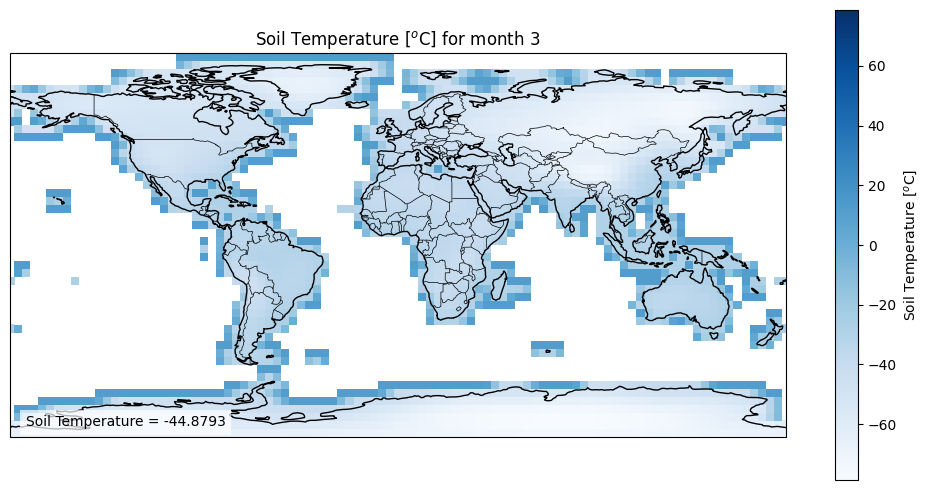

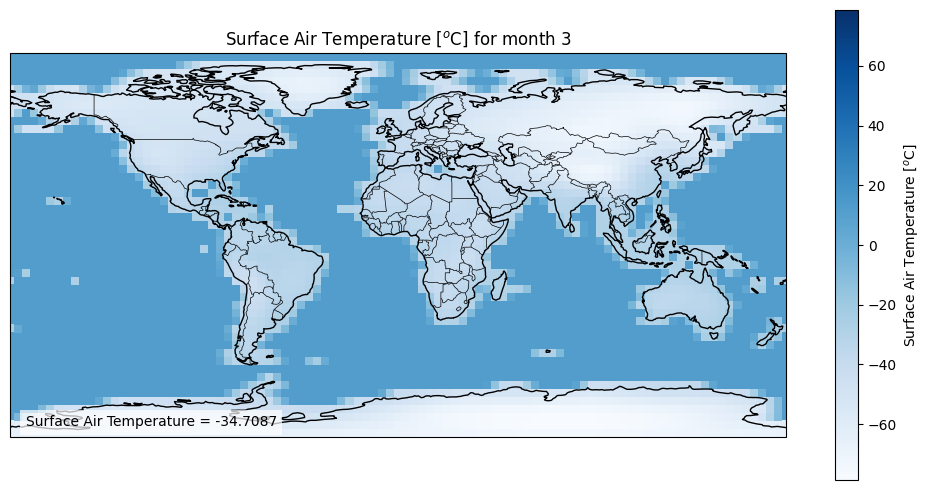

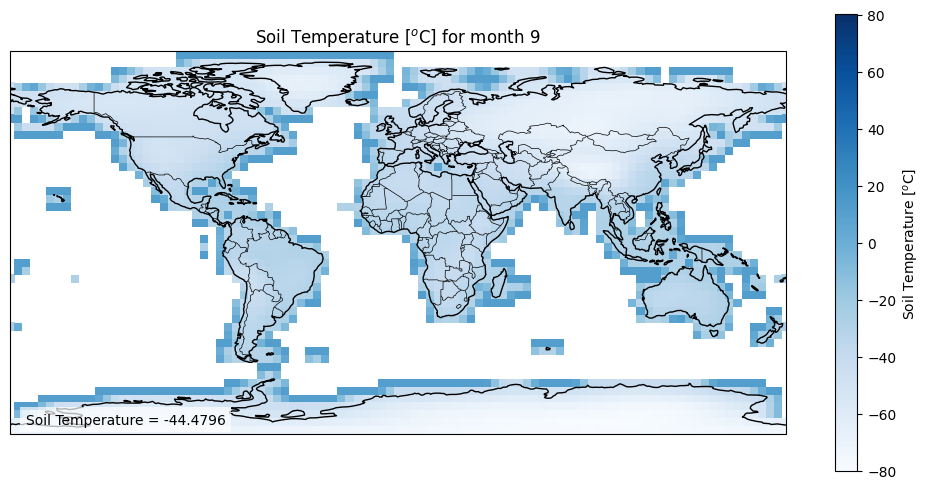

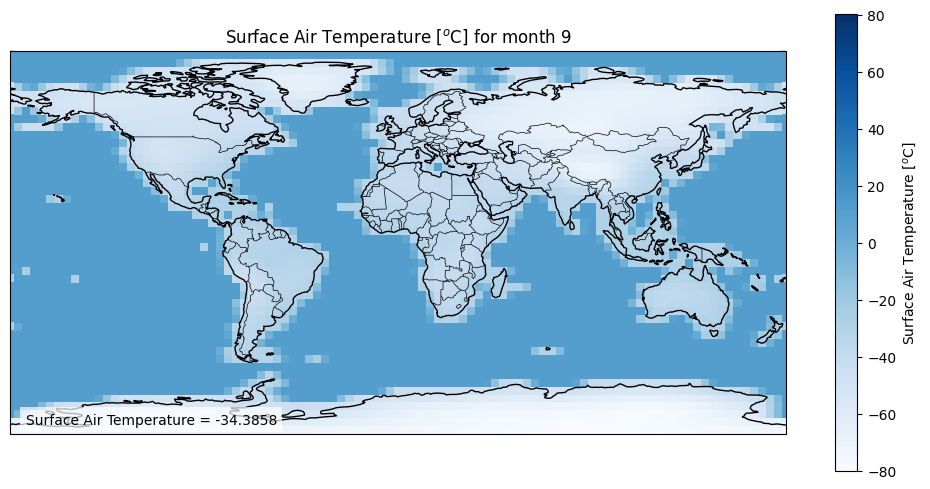

In [65]:
# Check where its snowing vs convectively raining

months_to_keep = [3,9]
for month, month_ds in grouped_data:
    if month in months_to_keep:

        st = month_ds["st"].isel(soil_layer=0)

        land = month_ds["lsm"]

        st_mean = st.mean("time")
        tsurf = month_ds["tsurf"]
        ts_mean = tsurf.mean("time")

        # Weights
        lat = land["lat"]
        weights = np.cos(np.deg2rad(lat))
        weights = weights.where(np.isfinite(weights), 0)
        weights_2d, _ = xr.broadcast(weights, land)

        # Area weighted fraction
        numerator_st = (st_mean * land * weights_2d).sum(dim=["lat", "lon"])
        denominator_st = (land * weights_2d).sum(dim=["lat", "lon"])
        frac_st = ( numerator_st / denominator_st )

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        st_mean.where(land).plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={"label": "Soil Temperature [$^o$C]"},
            cmap="Blues",
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"Soil Temperature = {frac_st:.4f}",
            transform=ax.transAxes,
            ha="left", va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        plt.title(f"Soil Temperature [$^o$C] for month {month}")
        plt.tight_layout() 

        # Weights
        lat = ts_mean.lat
        weights = np.cos(np.deg2rad(lat))
        weights = weights.where(np.isfinite(weights), 0)
        weights_2d, _ = xr.broadcast(weights, ts_mean)

        # Area weighted fraction
        numerator_ts = (ts_mean * weights_2d).sum(dim=["lat", "lon"])
        denominator_ts = (weights_2d).sum(dim=["lat", "lon"])
        frac_ts = ( numerator_ts / denominator_ts )

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        st_mean.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={"label": "Surface Air Temperature [$^o$C]"},
            cmap="Blues",
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"Surface Air Temperature = {frac_ts:.4f}",
            transform=ax.transAxes,
            ha="left", va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        plt.title(f"Surface Air Temperature [$^o$C] for month {month}")
        plt.tight_layout() 

In [67]:
print(ds_crop.variables)

Frozen({'time': <xarray.IndexVariable 'time' (time: 1460)> Size: 12kB
array(['2002-01-01T00:00:00.000000000', '2002-01-01T06:00:00.000000000',
       '2002-01-01T12:00:00.000000000', ..., '2002-12-31T06:00:00.000000000',
       '2002-12-31T12:00:00.000000000', '2002-12-31T18:00:00.000000000'],
      dtype='datetime64[ns]')
Attributes:
    long_name:      time
    standard_name:  time, 'lon': <xarray.IndexVariable 'lon' (lon: 96)> Size: 768B
array([  0.  ,   3.75,   7.5 ,  11.25,  15.  ,  18.75,  22.5 ,  26.25,  30.  ,
        33.75,  37.5 ,  41.25,  45.  ,  48.75,  52.5 ,  56.25,  60.  ,  63.75,
        67.5 ,  71.25,  75.  ,  78.75,  82.5 ,  86.25,  90.  ,  93.75,  97.5 ,
       101.25, 105.  , 108.75, 112.5 , 116.25, 120.  , 123.75, 127.5 , 131.25,
       135.  , 138.75, 142.5 , 146.25, 150.  , 153.75, 157.5 , 161.25, 165.  ,
       168.75, 172.5 , 176.25, 180.  , 183.75, 187.5 , 191.25, 195.  , 198.75,
       202.5 , 206.25, 210.  , 213.75, 217.5 , 221.25, 225.  , 228.75, 232.5 ,
  

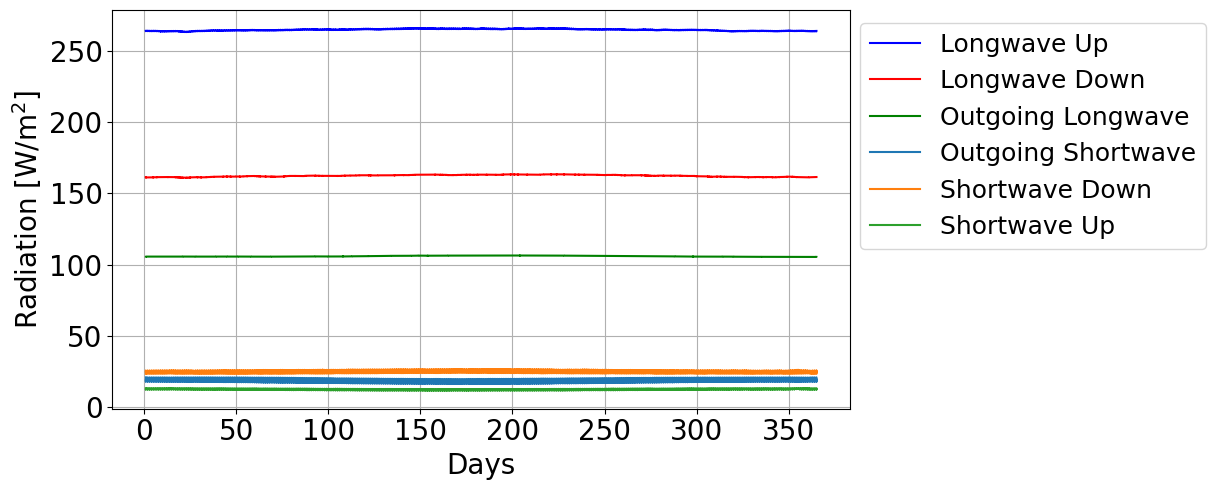

In [73]:
# Radiation budget
    # Surface longwave radiation up lru
    # Outgoing longwave radiation olr
    # Surface longwave radiation down lrd
    # Outgoing shortwave radiation osr
    # Surface shortwave radiation down srd
    # Surface shortwave radiation up sru

lru = WholeGlobeParam.globalparam_timeseries(ds_crop["lru"])
lrd = WholeGlobeParam.globalparam_timeseries(ds_crop["lrd"])
olr = WholeGlobeParam.globalparam_timeseries(ds_crop["olr"])
osr = WholeGlobeParam.globalparam_timeseries(ds_crop["osr"])
srd = WholeGlobeParam.globalparam_timeseries(ds_crop["srd"])
sru = WholeGlobeParam.globalparam_timeseries(ds_crop["sru"])

fig = plt.figure(figsize=(14, 5))
plt.plot(times, lru, color='blue', label="Longwave Up")
plt.plot(times, lrd, color='red', label="Longwave Down")
plt.plot(times, olr, color='green', label="Outgoing Longwave")
plt.plot(times, osr, label="Outgoing Shortwave")
plt.plot(times, srd, label="Shortwave Down")
plt.plot(times, sru, label="Shortwave Up")
plt.ylabel("Radiation [W/m$^2$]", size=20)
plt.xlabel('Days', size=20)
# plt.ylim(-100,-30)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18,  loc="upper right", bbox_to_anchor=(1.5, 1))
plt.tight_layout()
plt.show()